# Lib

In [4]:
import os
import cv2
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import models, transforms

In [5]:
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision.models import resnet50, ResNet50_Weights

# Load data

In [6]:
IMAGE_PATH = "/Users/quyduong106/projects/COMPSCI 760/mosquito_dataset_ai_v1/image_crop/train_00000_0_crop.jpeg"
CSV_PATH = "/Users/quyduong106/projects/COMPSCI 760/mosquito_dataset_ai_v1/image_crop/cropped_annotations.csv"
CKPT_PATH = "/Users/quyduong106/projects/COMPSCI 760/resnet50_pf_loss_lr0.0001_bs32_g1.0_wNone_best.pth"
OUT_PATH = "gradcam_train_00000_0_crop.jpg"

In [7]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [7]:
# Load labels
df = pd.read_csv(CSV_PATH)
classes = sorted(df["class_label"].unique())
num_classes = len(classes)
idx_to_class = {i: c for i, c in enumerate(classes)}

# Build ResNet50
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Load checkpoint
ckpt = torch.load(CKPT_PATH, map_location=device)

if isinstance(ckpt, dict):
    if "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
    elif "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    else:
        state_dict = ckpt
else:
    state_dict = ckpt


In [8]:
# Remove common prefixes
clean_state = {}
for k, v in state_dict.items():
    k = k.replace("module.", "")
    k = k.replace("model.", "")
    clean_state[k] = v

model.load_state_dict(clean_state, strict=False)
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# GradCAM
where the model looked broadly.

In [9]:
# Grad-CAM hooks
target_layer = model.layer4[-1]
activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output.detach()

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0].detach()

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# Preprocess image
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

pil_img = Image.open(IMAGE_PATH).convert("RGB")
input_tensor = preprocess(pil_img).unsqueeze(0).to(device)

In [10]:
# Forward pass
output = model(input_tensor)
pred_idx = output.argmax(dim=1).item()
pred_class = idx_to_class[pred_idx]
score = output[0, pred_idx]

# Backward pass
model.zero_grad()
score.backward()

# Compute Grad-CAM
weights = gradients.mean(dim=(2, 3), keepdim=True)
cam = (weights * activations).sum(dim=1).squeeze()
cam = torch.relu(cam)
cam = cam.cpu().numpy()

cam = cv2.resize(cam, pil_img.size)
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)

# Overlay heatmap
img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
overlay = cv2.addWeighted(img, 0.55, heatmap, 0.45, 0)

cv2.imwrite(OUT_PATH, overlay)

print(f"Predicted class: {pred_class}")
print(f"Class index: {pred_idx}")
print(f"Saved Grad-CAM to: {OUT_PATH}")

Predicted class: albopictus
Class index: 1
Saved Grad-CAM to: gradcam_train_00000_0_crop.jpg


## GradCam ++

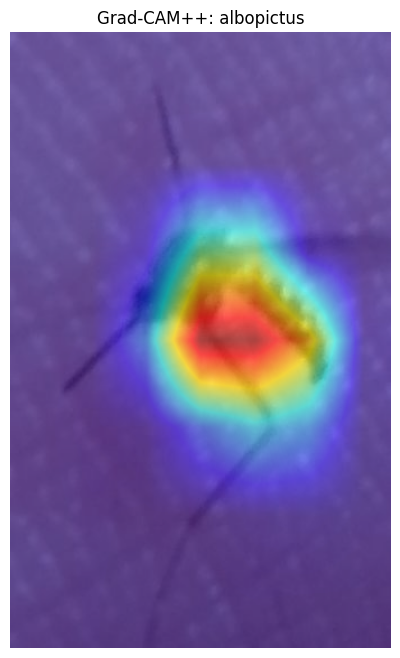

In [11]:
target_layers = [model.layer4[-1]]

cam = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[ClassifierOutputTarget(pred_idx)]
)[0]

# Keep original image size
rgb_img = np.array(pil_img).astype(np.float32) / 255.0
original_h, original_w = rgb_img.shape[:2]

# Resize CAM to original image size
grayscale_cam_resized = cv2.resize(
    grayscale_cam,
    (original_w, original_h)
)

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam_resized,
    use_rgb=True
)

plt.figure(figsize=(8, 8))
plt.imshow(visualization)
plt.title(f"Grad-CAM++: {pred_class}")
plt.axis("off")
plt.show()


# Intergrated Gradients - IG

Integrated Gradients = which pixels contributed to the decisions

In [14]:
from captum.attr import IntegratedGradients

model.eval()

# Integrated Gradients
ig = IntegratedGradients(model)

# Baseline = black image
baseline = torch.zeros_like(input_tensor).to(device)

attributions, delta = ig.attribute(
    input_tensor,
    baselines=baseline,
    target=pred_idx,
    return_convergence_delta=True
)

print("Attribution shape:", attributions.shape)
print("Convergence delta:", delta.item())

Attribution shape: torch.Size([1, 3, 224, 224])
Convergence delta: -0.3680691719055176


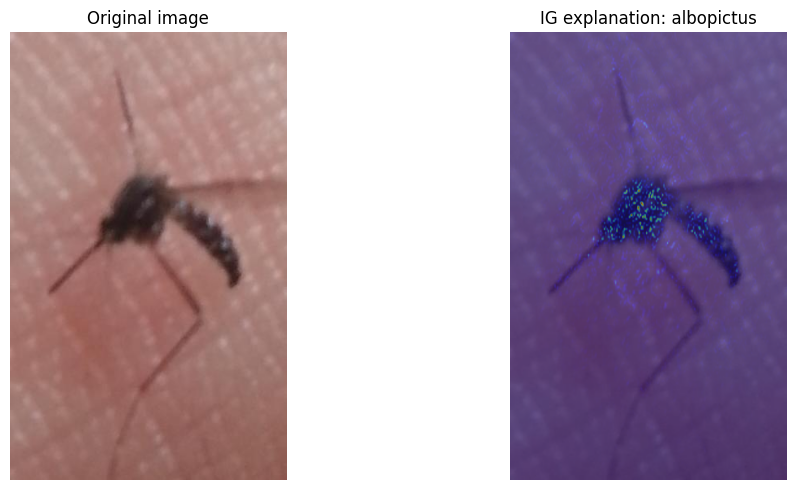

In [15]:
# Convert attribution tensor to image format: C,H,W -> H,W,C
attr = attributions.squeeze().detach().cpu().numpy()
attr = np.transpose(attr, (1, 2, 0))

# Sum attribution across RGB channels
attr_sum = attr.sum(axis=2)

# Normalize to [0, 1]
attr_sum = np.maximum(attr_sum, 0)  # keep positive evidence only
attr_sum = attr_sum - attr_sum.min()
attr_sum = attr_sum / (attr_sum.max() + 1e-8)

# Resize attribution map to original image size
attr_resized = cv2.resize(attr_sum, pil_img.size)

# Create heatmap
heatmap = cv2.applyColorMap(
    np.uint8(255 * attr_resized),
    cv2.COLORMAP_JET
)

# Original image in BGR for cv2 overlay
img_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

overlay = cv2.addWeighted(img_bgr, 0.55, heatmap, 0.45, 0)

# Convert BGR -> RGB for matplotlib
overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(pil_img)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay_rgb)
plt.title(f"IG explanation: {pred_class}")
plt.axis("off")

plt.tight_layout()
plt.show()

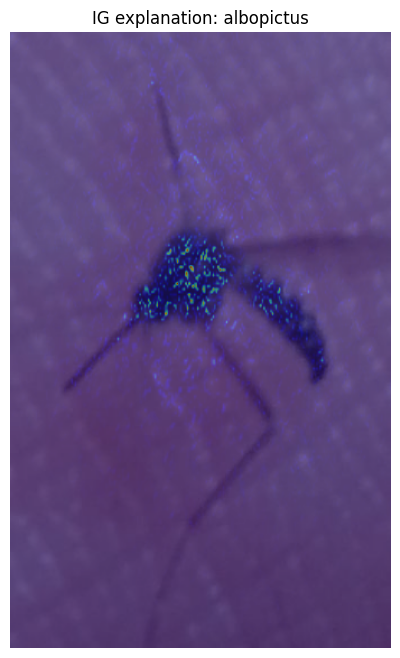

In [16]:
plt.figure(figsize=(8, 8))
plt.imshow(overlay_rgb)
plt.title(f"IG explanation: {pred_class}")
plt.axis("off")
plt.show()

# SmoothGrad
SmoothGrad lấy nhiều phiên bản ảnh có thêm nhiễu nhẹ, tính gradient cho từng ảnh, rồi lấy trung bình. Kết quả là bản đồ saliency ít nhiễu hơn.

Giải thích được gì?
Cho biết pixel/vùng nào ảnh hưởng mạnh đến dự đoán.

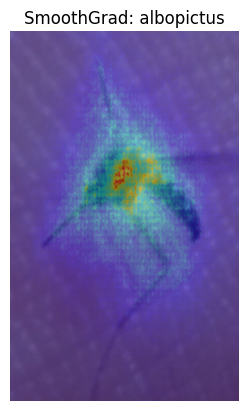

In [47]:
from captum.attr import Saliency, NoiseTunnel

saliency = Saliency(model)
smoothgrad = NoiseTunnel(saliency)

attr = smoothgrad.attribute(
    input_tensor,
    target=pred_idx,
    nt_type="smoothgrad",
    nt_samples=30,
    stdevs=0.1
)

attr_np = attr.squeeze().detach().cpu().numpy()
attr_np = np.transpose(attr_np, (1, 2, 0))
attr_map = np.abs(attr_np).mean(axis=2)

attr_map = (attr_map - attr_map.min()) / (attr_map.max() - attr_map.min() + 1e-8)
attr_map = cv2.resize(attr_map, pil_img.size)

heatmap = cv2.applyColorMap(np.uint8(255 * attr_map), cv2.COLORMAP_JET)
img_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
overlay = cv2.addWeighted(img_bgr, 0.55, heatmap, 0.45, 0)

plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"SmoothGrad: {pred_class}")
plt.axis("off")
plt.show()

In [1]:
import json
import os
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Paths
label_path = r"/Users/quyduong106/projects/COMPSCI 760/mosquito_dataset_ai_v1/labels/annotations.csv"
pred_path = r"/Users/quyduong106/projects/COMPSCI 760/test_predictions (1).json"

# Load ground truth labels
labels = pd.read_csv(label_path)

# Keep filename + true class
labels["filename"] = labels["img_fName"].apply(os.path.basename)
labels = labels[["filename", "class_label"]].rename(columns={"class_label": "y_true"})

# Load predictions JSON
with open(pred_path, "r") as f:
    preds_json = json.load(f)

pred_rows = []

for item in preds_json:
    filename = os.path.basename(item["image_path"])
    detections = item.get("detections", [])

    if len(detections) == 0:
        pred_class = "no_prediction"
        pred_score = None
    else:
        # Use detection with highest confidence score
        best_det = max(detections, key=lambda x: x.get("score", 0))
        pred_class = best_det["class_name"]
        pred_score = best_det.get("score", None)

    pred_rows.append({
        "filename": filename,
        "y_pred": pred_class,
        "score": pred_score
    })

preds = pd.DataFrame(pred_rows)

# Match predictions with ground truth
df = labels.merge(preds, on="filename", how="inner")

print("Number of matched images:", len(df))
print(df.head())

# True and predicted labels
y_true = df["y_true"]
y_pred = df["y_pred"]

# Metrics
accuracy = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Accuracy:", accuracy)
print("Balanced Accuracy:", balanced_acc)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1:", f1_macro)
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1:", f1_weighted)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, zero_division=0))

# Confusion matrix
classes = sorted(set(y_true) | set(y_pred))
cm = confusion_matrix(y_true, y_pred, labels=classes)

cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print("\nConfusion Matrix:")
print(cm_df)


Number of matched images: 1554
           filename      y_true      y_pred     score
0  train_00006.jpeg   anopheles  albopictus  0.527994
1  train_00009.jpeg  albopictus  albopictus  0.671042
2  train_00018.jpeg    culiseta    culiseta  0.920809
3  train_00027.jpeg       culex  albopictus  0.919743
4  train_00035.jpeg  albopictus  albopictus  0.791867
Accuracy: 0.5566280566280566
Balanced Accuracy: 0.3356692548803759
Macro Precision: 0.4095986347178888
Macro Recall: 0.28771650418317934
Macro F1: 0.2848847913875911
Weighted Precision: 0.7063126990219358
Weighted Recall: 0.5566280566280566
Weighted F1: 0.5218237353639678

Classification Report:
                    precision    recall  f1-score   support

           aegypti       0.00      0.00      0.00         4
        albopictus       0.54      0.92      0.68       683
         anopheles       0.33      0.20      0.25        10
             culex       0.91      0.27      0.42       693
          culiseta       0.82      0.20      0.

/Users/quyduong106/projects/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Confusion Matrix:


,aegypti,albopictus,anopheles,culex,culiseta,japonicus-koreicus,no_prediction
aegypti,0,2,0,0,0,1,1
albopictus,2,625,1,14,2,29,10
anopheles,0,7,2,0,1,0,0
culex,1,432,3,189,1,39,28
culiseta,0,51,0,3,18,17,3
japonicus-koreicus,1,36,0,2,0,31,2
no_prediction,0,0,0,0,0,0,0


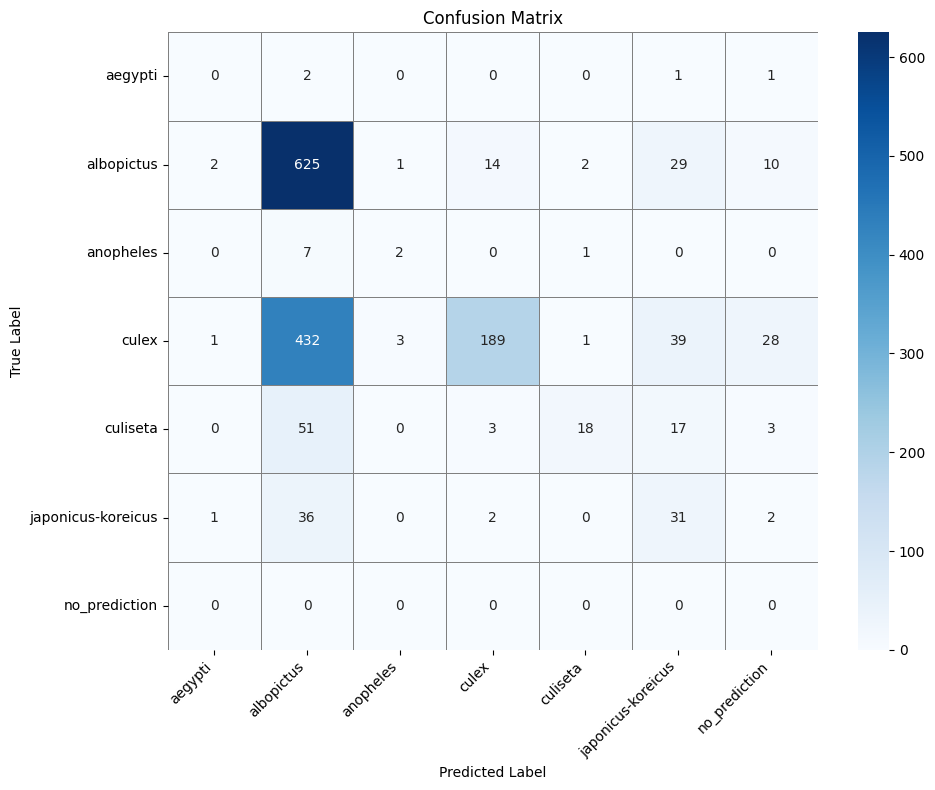

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Class names
classes = sorted(set(y_true) | set(y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)

# Convert to DataFrame for readable labels
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

print("Confusion Matrix:")
display(cm_df)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [3]:
import os
import json
import shutil
import pandas as pd
from pathlib import Path

# Paths
image_dir = Path(r"/Users/quyduong106/projects/COMPSCI 760/mosquito_dataset_ai_v1/images")
label_path = Path(r"/Users/quyduong106/projects/COMPSCI 760/mosquito_dataset_ai_v1/labels/annotations.csv")

# Output folder
output_dir = Path(r"/Users/quyduong106/projects/COMPSCI 760/manual_labeling_split")
output_dir.mkdir(parents=True, exist_ok=True)

people = ["SOphia", "Youmin", "JInghao", "Duong"]

# Load labels
df = pd.read_csv(label_path)

# Make sure image filename column exists
print(df.head())
print(df.columns)

# Shuffle within each species/class so each person gets a balanced mix
split_dfs = {person: [] for person in people}

for class_name, group in df.groupby("class_label"):
    group = group.sample(frac=1, random_state=42).reset_index(drop=True)

    for i, (_, row) in enumerate(group.iterrows()):
        person = people[i % len(people)]
        split_dfs[person].append(row)

# Save images and labels for each person
for person in people:
    person_dir = output_dir / person
    person_image_dir = person_dir / "images"
    person_label_dir = person_dir / "labels"

    person_image_dir.mkdir(parents=True, exist_ok=True)
    person_label_dir.mkdir(parents=True, exist_ok=True)

    person_df = pd.DataFrame(split_dfs[person])

    # Copy images
    missing_images = []

    for img_name in person_df["img_fName"]:
        src = image_dir / img_name
        dst = person_image_dir / img_name

        if src.exists():
            shutil.copy2(src, dst)
        else:
            missing_images.append(img_name)

    # Save CSV labels
    csv_output_path = person_label_dir / "annotations.csv"
    person_df.to_csv(csv_output_path, index=False)

    # Save JSON labels
    json_records = []

    for _, row in person_df.iterrows():
        record = {
            "image": row["img_fName"],
            "image_width": int(row["img_w"]),
            "image_height": int(row["img_h"]),
            "class_label": row["class_label"],
            "bbox": {
                "xtl": float(row["bbx_xtl"]),
                "ytl": float(row["bbx_ytl"]),
                "xbr": float(row["bbx_xbr"]),
                "ybr": float(row["bbx_ybr"])
            }
        }
        json_records.append(record)

    json_output_path = person_label_dir / "annotations.json"

    with open(json_output_path, "w") as f:
        json.dump(json_records, f, indent=4)

    print(f"{person}:")
    print(f"  Images: {len(person_df)}")
    print(f"  CSV: {csv_output_path}")
    print(f"  JSON: {json_output_path}")

    if missing_images:
        print(f"  Missing images: {len(missing_images)}")
        print(missing_images[:10])

print("Done.")
 

          img_fName  img_w  img_h  bbx_xtl  bbx_ytl  bbx_xbr  bbx_ybr  \
0  train_00000.jpeg   2448   3264     1301     1546     1641     2096   
1  train_00001.jpeg   3024   4032      900     1897     1950     2990   
2  train_00002.jpeg    768   1024      220       58      659      808   
3  train_00003.jpeg   3456   4608     1169     2364     1586     2826   
4  train_00004.jpeg   1024   1365      129      231      697     1007   

  class_label  
0  albopictus  
1  albopictus  
2  albopictus  
3  albopictus  
4       culex  
Index(['img_fName', 'img_w', 'img_h', 'bbx_xtl', 'bbx_ytl', 'bbx_xbr',
       'bbx_ybr', 'class_label'],
      dtype='object')
SOphia:
  Images: 2591
  CSV: /Users/quyduong106/projects/COMPSCI 760/manual_labeling_split/SOphia/labels/annotations.csv
  JSON: /Users/quyduong106/projects/COMPSCI 760/manual_labeling_split/SOphia/labels/annotations.json
Youmin:
  Images: 2590
  CSV: /Users/quyduong106/projects/COMPSCI 760/manual_labeling_split/Youmin/labels/annotatio

In [8]:
import json
import pandas as pd
from pathlib import Path

# Paths
image_dir = Path(r"/Users/quyduong106/projects/COMPSCI 760/manual_labeling_split/Duong/images")
csv_path = Path(r"/Users/quyduong106/projects/COMPSCI 760/manual_labeling_split/Duong/labels/annotations.csv")

# Load labels
df = pd.read_csv(csv_path)

# Create one JSON per image
for img_name, group in df.groupby("img_fName"):
    first = group.iloc[0]

    shapes = []

    for _, row in group.iterrows():
        shape = {
            "label": str(row["class_label"]),   # species name
            # If you want numeric labels instead, change this line to:
            # "label": "1",
            "text": "",
            "points": [
                [
                    float(row["bbx_xtl"]),
                    float(row["bbx_ytl"])
                ],
                [
                    float(row["bbx_xbr"]),
                    float(row["bbx_ybr"])
                ]
            ],
            "group_id": None,
            "shape_type": "rectangle",
            "flags": {}
        }

        shapes.append(shape)

    json_data = {
        "version": "0.4.36",
        "flags": {},
        "shapes": shapes,
        "imagePath": img_name,
        "imageData": None,
        "imageHeight": int(first["img_h"]),
        "imageWidth": int(first["img_w"])
    }

    json_path = image_dir / img_name.replace(".jpeg", ".json")

    with open(json_path, "w") as f:
        json.dump(json_data, f, indent=2)

print("Done. JSON files created inside:")
print(image_dir)


Done. JSON files created inside:
/Users/quyduong106/projects/COMPSCI 760/manual_labeling_split/Duong/images


In [9]:
from pathlib import Path
import shutil
import math

image_dir = Path(r"/Users/quyduong106/projects/COMPSCI 760/manual_labeling_split/Duong/images")

output_dir = image_dir.parent / "images_split_200"
output_dir.mkdir(parents=True, exist_ok=True)

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

images = sorted([
    p for p in image_dir.iterdir()
    if p.is_file() and p.suffix.lower() in image_exts
])

chunk_size = 200

print(f"Found {len(images)} images")
print(f"Creating {math.ceil(len(images) / chunk_size)} folders")

for i in range(0, len(images), chunk_size):
    chunk = images[i:i + chunk_size]
    folder_num = i // chunk_size + 1
    chunk_dir = output_dir / f"batch_{folder_num:03d}"
    chunk_dir.mkdir(parents=True, exist_ok=True)

    for img_path in chunk:
        # Copy image
        shutil.copy2(img_path, chunk_dir / img_path.name)

        # Copy matching JSON if it exists
        json_path = img_path.with_suffix(".json")
        if json_path.exists():
            shutil.copy2(json_path, chunk_dir / json_path.name)
        else:
            print(f"Missing JSON for: {img_path.name}")

    print(f"{chunk_dir.name}: {len(chunk)} images")

print("Done.")
print(f"Output folder: {output_dir}")


Found 2587 images
Creating 13 folders
batch_001: 200 images
batch_002: 200 images
batch_003: 200 images
batch_004: 200 images
batch_005: 200 images
batch_006: 200 images
batch_007: 200 images
batch_008: 200 images
batch_009: 200 images
batch_010: 200 images
batch_011: 200 images
batch_012: 200 images
batch_013: 187 images
Done.
Output folder: /Users/quyduong106/projects/COMPSCI 760/manual_labeling_split/Duong/images_split_200
